# 타이타닉 분석

# 분석목적
# 타이타닉 생존 여부에 영향을 미친 주요 요인에 대한 체계적 분석

In [ ]:
# 1 . 데이터 수집
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt

from google.colab import drive
drive.mount('/content/drive')
df_train = pd.read_csv('/content/drive/My Drive/Colab Notebooks/titanic/train.csv')

#엑셀로 저장
df_train.to_excel("titanic.xlsx")
#df_train


In [ ]:
# 2. 전처리
# 2-1) 구조진단
df_train.info()

# 분석 = 인사이트 
# 컬럼명을 한글로 분석완료 하였음
# 3개의 컬럼에서 결측치 보인다.
# 총 13 개의 컬럼에서 891 행의 데이터가 있다.

df_train.head(5)
#분석
df_train.shape
#13 개의 컬럼에 891명의 개인정보가 포함되어있다.


In [ ]:
!pip install missingno

In [ ]:
import missingno as msno
# 2-2) 정제 (결측치, 이상치)
df_train.isnull().sum()
msno.matrix(df_train) 

missing_pct = (df_train.isnull().sum() / len(df_train) * 100).sort_values(ascending=False)
print(missing_pct)

# 1)순수 데이터 분석만 할시는 데이터 정제 및 결측치 이상치 처리할 필요 없음

# Age 결측치 처리
# 20%면 버리기 아까움. = 결측이 너무 많지는 않음
# 판단 => 채우는 방향으로 
# Age 연속형 데이타
# 숫자는 => 평균 ,중앙값, 최빈값, 최대최소 , 예측값으로 결측값을 채울수 있음
df_train["Age"].skew() #왜도 체크 값(0.38)
# 왜도 체크 => 분포가 약간 치우침

# | 왜도 값       | 해석      |
# | ---------- | ------- |
# | -0.5 ~ 0.5 | 거의 대칭   |
# | ±0.5 ~ ±1  | 약간 치우침  |
# | ±1 이상      | 강하게 치우침 |

df_train["Age"] = df_train["Age"].fillna(df_train["Age"].median())


# Cabin: => 77% 
# 결측률이 너무큼
# 채워도 의미 없음
# 해당행 제거시 더 큰 위험
# 제거 고려

# 결측률   판단
# < 10% 대체
# 10~30% > 상황 판단
# 30~50% 신중
# 50% 제거 고려

df_train.drop(columns=["Cabin"],errors="ignore",inplace=True)

# Embarked 처리
# 2/ 891 결측률 0.2%
# 범주형 데이터
# 최빈값으로 대체

df_train["Embarked"] = df_train["Embarked"].fillna(df_train["Embarked"].mode()[0])

# 전처리 판단기준
# 1. 결측률 체크
# 2. 컬럼 타입 체크
# 3. 데이터 분포
# 4. 채우면 왜곡 되는 가?
# 5. 제거하면 손실이 큰가

# 분석, 인사이트 발견
# Age,
# → 숫자형 + 20%,
# → 중앙값,
# Cabin,
# → 77%,
# → 컬럼 제거,
# Embarked,
# → 범주형 + 0.2%,
# → 최빈값


In [ ]:
# 2-3) 문자열 및 시계열 처리


# 예제)
# 1.이름이 생존률과 차이및 관계가 있을까?
# 2.예측에 도움이 되는 정보는 아님
# 3.범주형이 아니어서 그룹별로 취할수 없는 정보가 없음

# | Name                       | Title |
# | -------------------------- | ----- |
# | Braund, Mr. Owen Harris    | Mr    |
# | Cumings, Mrs. John Bradley | Mrs   |
# | Heikkinen, Miss. Laina     | Miss  |

# Braund, Mr. Owen Harris
#          ↑
# 추출 결과
# Mr

df_train["Title"] = df_train["Name"].str.extract(" ([A-Za-z]+)\.")
# | Title  | 의미    |
# | ------ | ----- |
# | Mr     | 성인 남성 |
# | Mrs    | 기혼 여성 |
# | Miss   | 미혼 여성 |
# | Master | 어린 남자 |

# Name 그대로 쓰지 않은 이유
# 1. 모든 이름이 유일함
# 2. 데이터 종류 너무 많아짐
# 3. 일반화가 어려워짐

df_train

In [ ]:
# 2-4) 정리 및 변환
# 불필요한 컬럼 제거
# 단순한 컬럼수 줄이기는 아님
# 예측및 분석에 도움이 되는 정보인지 체크. 예) 중복인가, 식별자인가?
# 를 판단해서 제거

# PassengerId
# 승객번호 1번이라 생존했나?
# 승객번호 10번이라 사망했나?
# 번호와 생존은 상관없음

# 실무 에서는 아래를 제거
# 고유번호
# Primary Key
# ID
# UUID => 범용 고유 식별자(예)네트워크 카드의 맥주소)

# Name 컬럼

# 예시
# Braund, Mr. Owen Harris
# Cumings, Mrs. John Bradley

# 문제:
# 이름 종류가 너무 많음.
# 891명인데
# Name 고유값 ≈ 891개
# 거의 전부 다름.

# Braund → ?
# Owen → ?
# 그래서 # Mr # Mrs # Miss # Master 추출후 제거

# Ticket
# 예시

# A/5 21171
# PC 17599
# STON/O2 3101282

# 생존률과는 연관짓기가 힘듬
df_train["Ticket"].nunique()
# 681
# 891명 중
# 681개 종류
# 너무 많음.

# 분석 및 인사이트

# 컬럼               제거 이유
# PassengerId      단순 식별자
# Name              고유값 과다
# Ticket          종류 과다 + 의미 약함

df_train.drop(["PassengerId","Name","Ticket"],axis=1,inplace=True)
df_train

In [ ]:
# 피처 엔지니어링
# 피처 엔지니어링(Feature Engineering) 은 데이터 분석/머신러닝에서 가장 중요한 단계 중 하나임
# 한 줄 정의부터:
# 기존 데이터를 더 의미 있는 변수(Feature)로 변환하거나 새로 만드는 작업

# 원본 데이터
# ↓
# 모델이 이해하기 쉬운 정보로 가공

# 피처엔지니어링 이해하기

# | 종류    | 예시        |
# | ----- | --------- |
# | 결합    | 키+몸무게→BMI |
# | 분할    | 날짜→연·월·요일 |
# | 구간화   | 나이→연령대    |
# | 문자 추출 | 이름→호칭     |
# | 집계    | 구매금액→평균   |
# | 변환    | 로그 변환     |

# 전처리
# → 데이터를 깨끗하게 만드는 작업

# 피처 엔지니어링
# → 데이터를 똑똑하게 만드는 작업

df_train

# FamilySize 생성
# 원본
# sister(형제) + brother(자매) + Spouse(배우자)
# Parent + child 
# SibSp    Parch
# 1          0
# 2          1

# | 상황          | SibSp |
# | -----------   | ----: |
# | 혼자 탑승       |     0 |
# | 배우자와 탑승     |     1 |
# | 형 1명과 탑승    |     1 |
# | 형제 2명 + 배우자 |     3 |

# | 상황            | Parch |
# | ------------- | ----: |
# | 혼자            |     0 |
# | 부모 1명         |     1 |
# | 자녀 2명         |     2 |
# | 부모 2명 + 자녀 1명 |     3 |

# 2-5) 재구조화
# FamilySize 생성
# 탑승 가족수, 재구조화

df_train["FamilySize"] = df_train["SibSp"] + df_train["Parch"] + 1

df_train

In [ ]:
# 2-6)스케일링

# vi) 스케일링
# 1. 스케일링이란?
# 한 줄 정의:
# 서로 다른 크기의 숫자를 비슷한 기준으로 맞추는 것
# 머신러닝 딥러닝 에서 주로 수행
# 데이터 분석시에서 스케일링이 필요 없을수도 있음

# | Age |  Fare |
# | --: | ----: |
# |  22 |  7.25 |
# |  38 | 71.28 |
# |  35 | 53.10 |

# 문제:

# Age   → 0~80
# Fare  → 0~500

# 크기 차이가 큼.
# | 모델      | 스케일링 |
# | ------- | ---- |
# | 로지스틱 회귀 | 추천   |
# | KNN     | 필수   |
# | SVM     | 필수   |
# | 신경망     | 추천   |
# | 트리      | 불필요  |
# | 랜덤포레스트  | 불필요  |

In [ ]:
# vii) 정보 조합 · 파생변수
# 피처 엔지니어링(Feature Engineering) 에서 아주 많이 쓰는 구간화(Binning)
# 연속형 변수를 범주형 변수로 변환

df_train["AgeGroup"] = pd.cut(df_train["Age"],bins=[0,18,40,60,100])
df_train

# df_train["AgeGroup"] = pd.cut(
#     df_train["Age"],
#     bins=[0,18,40,60,100],
#     labels=[
#         "Child",
#         "Adult",
#         "Middle",
#         "Old"
#     ]
# )

df_train.groupby("AgeGroup")["Survived"].mean()

# 어린이 생존률 높음
# 고령층 생존률 낮음

# 인사이트
# 어린이 우선 구조 했을 가능성이 큼


In [ ]:
# 3. EDA (탐색적 데이터 분석)

## 1) 기초통계량 확인
## 2) 단변량 분석


In [ ]:
## 1) 기초통계량 확인
df_train.describe()
df_train.describe().T

# 분석
# 1. Survived
# 평균 0.383
# 전체 승객중 약 38% 생존 약 62% 사망

# 2. Pclass 객실등급
# 평균 : 2.31
# 중앙값 : 3

# 객실:
# 1 → 상류층
# 2 → 중산층
# 3 → 일반석

# 해석:

# 평균이 2.3
# 중앙값이 3
# 3등석 승객 많음.
# 즉
# 데이터가 하위 객실에 치우침

# Age = 나이
# 평균 : 29.36
# 표준편차 : 13.0

# 최소 : 0.42
# Q1 : 22
# 중앙값 : 28
# Q3 : 35
# 최대 : 80
# 평균

# 평균 승객 나이 ≈ 29세
# 중앙값 절반은 28세 이하
# Q1  25% 승객 22세 이하
# Q3 75% 승객 35세 이하
# 최대 80세 존재 노인 존재
# 평균 29.36
# 중앙값 28
# 차이 작음
# 큰 왜도 없음
# 약간 우측 치우침

# SibSp (형제, 자매, 배우자수)
# 평균 : 0.52
# 최대 : 8

# 대부분 혼자 또는 1명 동반
# 대가족 8명 탑승 존재
# 중앙값 0 => 절반이상이 혼자 탑승

# Parch (부모 - 자녀수)
# 평균 : 0.38
# 중앙값 0
# 최대 6

# 대부분 부모-자녀없이 탑승
# 일부 가족 승객 있음

#Fare(운임)
# 평균 : 32
# 중앙값 14
# 최대 : 512 => 차이가 큼
# 오른쪽 꼬리 => 고가 티켓이 존재
# Q1 = 7 , Q3 = 31
# 50% 승객 7 ~ 31 그런데 최대 512 => 엄청 비싼 표가 있으며 평균의 왜곡 가능성 있음

#기초 통계량 분석 및 인사이트
# 1. 생존률 약 38%
# 2. 평균 나이 29세
# 3. 절반이상 가족없이 탑승
# 4. 운임은 우측편향 있음
# 5. Age는 큰 이상치는 없으며, 중앙값으로 대체가 적절

In [ ]:
## 2) 단변량 분석
# 컬럼 하나만 보고 분포 및 특징 이상치를 이해하는 분석

# 단변량 분석시
# 목적에 부합하고 도메인 지식이 있으면, 중요하다고 생각되는 컬럼 분석 실시

# 1. 생존 (Survived)
# 2. 나이 (Age)
# 3. 객실등급(Pclass)
# 4. 운임(Fare)




In [ ]:
# df_train["Survived"].value_counts()

# Survived (생존 여부) 단변량 분석

# count = (
#     df_train["Survived"]
#     .value_counts()
# )

# print("빈도수")
# print(count)

# print()

# 비율

# ratio = (
#     df_train["Survived"]
#     .value_counts(
#         normalize=True
#     )
#     * 100
# )

# print("비율(%)")
# print(
#     ratio.round(2)
# )

# # 시각화
# plt.figure(
#     figsize=(8,5)
# )


# ax = sns.countplot(
#     x="Survived",
#     data=df_train
# )

# # 막대 위 수치 출력

# for p in ax.patches:

#     height = p.get_height()

#     ax.annotate(
#         f"{height}",
#         (
#             p.get_x()
#             +
#             p.get_width()/2,
#             height
#         ),
#         ha="center",
#         va="bottom"
#     )


# plt.title(
#     "Survived Distribution"
# )

# plt.show()

# 인사이트 도출
# 전체 승객의 약 62%가 사망
# 생존률은 약 38%
# 데이터가 사망 쪽으로 약간 치우쳐 있음


# | X       | Y       | 목적          | 추천 그래프 | Pandas / Seaborn |
# | ------- | ------- | ---------     | ------    | ---------------- |
# | 범주형   | 수치형   | 그룹 비교      | 막대그래프  | `barplot()`      |
# | 범주형   | 수치형   | 분포 비교      | 박스플롯    | `boxplot()`      |
# | 범주형   | 수치형   | 분포 + 밀도    | 바이올린플롯 | `violinplot()`   |
# | 범주형   | 수치형   | 평균 + 신뢰구간 | 포인트플롯  | `pointplot()`    |
# | 범주형   | 범주형   | 개수 비교      | 카운트플롯  | `countplot()`    |
# | 범주형   | 범주형   | 비율 비교      | 누적막대    | `crosstab()`     |
# | 수치형   | 수치형   | 관계 분석      | 산점도      | `scatterplot()`  |
# | 수치형   | 수치형   | 상관관계       | 회귀플롯    | `regplot()`      |
# | 수치형   | 수치형   | 분포           | 히스토그램  | `histplot()`     |
# | 수치형   | 수치형   | 분포 밀도      | KDE        | `kdeplot()`      |
# | 시간     | 수치형   | 변화 추세      | 라인플롯    | `lineplot()`     |
# | 수치형 여러개 | 수치형 여러개 | 상관 비교     | 히트맵    | `heatmap()`  |

In [ ]:
# 2. 나이

# print(
# df_train["Age"]
# .describe()
# )

# sns.histplot(
# df_train["Age"],
# bins=20
# )

# plt.show()

# 분석
# 20 ~ 30세 가장 많음
# 어린아이 존재
# 노인 존재
# 약간 우측 왜도 현상이 있음



In [ ]:
# 3. Pclass 객실 등급

# count = df_train["Pclass"].value_counts()
# print(count)

# ratio = df_train["Pclass"].value_counts(normalize=True) * 100

# print(ratio.round(2))

# ax=sns.countplot(
# x="Pclass",
# data=df_train
# )

# for p in ax.patches:

#  ax.annotate(
#   p.get_height(),

#  (
#  p.get_x()+0.3,
#  p.get_height()
#  )
#  )


# 분석
# 1. 3등석 숭객 비율 가장 큼 55.11%
# 2. 하위 객실 승객 많음
# 3. 1등급 고객이 2등급 승객 보다 더 많음



In [ ]:
# 4. SibSp (형제,배우자 수)

count = df_train["SibSp"].value_counts()
print(count)

ratio = df_train["SibSp"].value_counts(normalize=True) * 100
print(ratio)


ax=sns.countplot(
x="SibSp",
data=df_train
)

for p in ax.patches:

 ax.annotate(
  p.get_height(),

 (
 p.get_x()+0.3,
 p.get_height()
 )
 )



#분석

# 대부분 혼자 탑승
# 일부는 가족과 함께 탑승


In [ ]:
# 5. Parch (부모·자녀 수)

count = df_train["Parch"].value_counts()
print(count)

ratio = df_train["Parch"].value_counts(normalize=True) * 100
print(ratio)

ax=sns.countplot(
x="Parch",
data=df_train
)

for p in ax.patches:

 ax.annotate(
  p.get_height(),
 (
 p.get_x()+0.3,
 p.get_height()
 )
 )


# 분석
# 대부분 혼자 탑승 76%
# 부모 또는 자식과 함께 탄 케이스는 21% 정도임

In [ ]:
# 6. Fare 운임
print(df_train["Fare"].describe())
# 수치형 연속형
sns.histplot(df_train["Fare"],bins=20)
# 분석
# 대부분의 승객이 50달러 미만 20~30 달러 구간에 몰려 있다.

In [ ]:
# 이변량 분석
# 변수 2개 사이의 관계를 분석하는것

# 1.수치 확인
# ↓
# 2.시각화
# ↓
# 3. 해석

# 도메인 지식이 있는 경우
# ↓
# 의미 있는 조합 선정
# ↓
# 이변량 분석

# 의미 있는 조합을 먼저 고려
# 1. Sex ↔ Survived
# 2. Pclass ↔ Survived
# 3. Age ↔ Survived
# 4. Fare ↔ Survived
# 5. FamilySize ↔ Survived


# 도메인 지식이 없는 경우
# 전체 변수 상관관계 확인
# ↓
# 관계가 큰 변수 선택
# ↓
# 이변량 분석

# 기초통계량
# ↓
# 단변량 분석
# ↓
# 상관관계 분석 (Heatmap)
# ↓
# 이변량 분석
# ↓
# 다변량 분석

# 실제 분석시는 위의 두 조합을 전부 고려


In [ ]:

# 1) Sex ↔ Survived
# 질문) 성별에 따른 생존률 차이가 있는가?
# result = pd.crosstab(df_train["Sex"],df_train["Survived"])
# print(result)

result = pd.crosstab(df_train["Sex"],df_train["Survived"],normalize="index") * 100
print(result)

# plt.figure(figsize=(8,5))

ax = sns.barplot(
    x="Sex",
    y="Survived",
    data=df_train
)

for p in ax.patches:
    value = p.get_height()*100
    ax.annotate(
        f"{value:.1f}%",
        (
            p.get_x()+p.get_width()/2,
            p.get_height()
        ),
        ha="center",
        va="bottom"
    )

    # 분석
    # 여성 생존률 약 74%
    # 남성 생존률 약 19%
    # 성별 차이가 매우 큼
    # 생존을 설명하는 강력한 변수 후보임

In [ ]:
# Age ↔ Survived
# 나이에 따른 생존률 차이가 잇는가?

result = df_train.groupby("Survived")["Age"].describe()
print(result)

# 사망 평균 나이 : 30.0
# 생존 평균 나이 : 23.

sns.boxplot(x="Survived",y="Age",data=df_train)

#
# 차이는 크지않음
# 나이 단독 영향은 약함

In [ ]:
# Pclass ↔ Survived
# 객실 등급에 따라 생존률 차이가 있는가?
result = pd.crosstab(df_train["Pclass"], df_train["Survived"],normalize="index") * 100
print(result)

ax = sns.barplot(
    x="Pclass",
    y="Survived",
    data=df_train
)

for p in ax.patches:

    percent = p.get_height()*100

    ax.annotate(
        f"{percent:.1f}%",
        (
            p.get_x()
            +
            p.get_width()/2,
            p.get_height()
        ),

        ha="center",
        va="bottom"
    )


# 분석 
# 1등석 생존률 63%
# 2등석 생존률 47%
# 3등석 생존률 24%
# 객실 등급이 낮아질수록 생존률 감소
# 생존률을 설명하는 중요한 변수라고 여겨진다.

In [ ]:
# Fare ↔ Survived

result = df_train.groupby("Survived")["Fare"].describe()
print(result)


ax = sns.barplot(
    x="Survived",
    y="Fare",
    data=df_train
)

for p in ax.patches:
    value = p.get_height()
    ax.annotate(
        f"{value:.1f}",
        (
            p.get_x() + p.get_width()/2,
            value
        ),
        ha="center",
        va="bottom"
    )

# 분석
# 사망 평균 요금 : 22
# 생존 평균 요금 : 48
# 운임이 높은 승객의 생존률이 더 높음



In [ ]:
# FamilySize ↔ Survived

result = df_train.groupby("FamilySize")["Survived"].mean()*100
print(result.round(1))

ax = sns.lineplot(x="FamilySize",y="Survived",data=df_train)
# 분석
# 혼자 탑승시 생존률 낮음
# 2~4명 가족은 생존률이 50% 가 넘음
# 가족이 많으면 생존률이 감소(50% 미만)


In [ ]:
df_train["AgeGroup"] = pd.cut(df_train["Age"],bins=[0,18,40,60,100])

# df_train["AgeGroup"] = pd.cut(
#     df_train["Age"],
#     bins=[0,18,40,60,100],
#     labels=[
#         "Child",
#         "Adult",
#         "Middle",
#         "Old"
#     ]
# )

df_train.groupby("AgeGroup")["Survived"].mean()
# 어린이 생존률 높음
# 고령층 생존률 낮음

#인사이트
# 어린이 우선 구조 했을 가능성이 큼

In [ ]:

#이변량 분석 결과

# | 조합                    | 결론       |
# | --------------------- | --------    |
# | Sex ↔ Survived        | 매우 강한 차이 |
# | Pclass ↔ Survived     | 강한 영향    |
# | Age ↔ Survived        | 영향 작음    |
# | Fare ↔ Survived       | 양의 관계    |
# | FamilySize ↔ Survived | 비선형 관계   |

In [ ]:
# 다변량 분석
# 3개 이상의 변수를 동시에 보고 패턴을 찾는 것


# 중요했던 변수들 위주로 조합

# 1. Sex + Pclass → Survived
# 2. Fare + Pclass → Survived
# 3. Age + FamilySize → Survived

In [ ]:
# 1. Sex + Pclass → Survived

result = pd.crosstab([df_train["Sex"],df_train["Pclass"]],df_train["Survived"],normalize="index")*100
print(result.round(1))

# 분석
# 1등석 여성 생존률이 압도적 이다.
# 남성은 등급 낮을수록 생존률이 급감
# 성별 효과가 객실에서 강하게 나타난다. 

ax=sns.barplot(
x="Pclass",
y="Survived",
hue="Sex",
data=df_train
)

for p in ax.patches:
 value=p.get_height()*100
 ax.annotate(
 f"{value:.1f}%",
 (
 p.get_x()
 +
 p.get_width()/2,
 p.get_height()
 ),
 ha="center"
 )

In [ ]:
# Fare + Pclass → Survived

result = df_train.groupby(["Pclass","Survived"])["Fare"].mean()
print(result)

sns.scatterplot(
    x="Fare",
    y="Pclass",
    hue = "Survived",
    data = df_train
)
# 분석
# 운임이 높을수록 생존률이 증가 하는 경향이 있다
# 이는 높은 운임을 지불한 승객이 주로 상위 객실(1등석)에 탑승했으며,
# 상위 객실 승객이 구조 과정에서 상대적으로 유리했기 때문으로 해석할 수 있다.

# Fare → Survived (x)
# Fare
# ↓
# Pclass
# ↓
# Survived (O)
# 운임 자체보다 객실 등급이 생존을 설명하는 핵심 변수일 가능성이 있다.

FamilySize  Survived
1           0           31.2
            1           31.0
2           0           31.6
            1           30.4
3           0           31.3
            1           22.5
4           0           24.1
            1           17.0
5           0           20.7
            1           31.0
6           0           17.6
            1           23.7
7           0           14.9
            1           15.8
8           0           15.7
11          0           28.0
Name: Age, dtype: float64


<Axes: xlabel='Age', ylabel='FamilySize'>

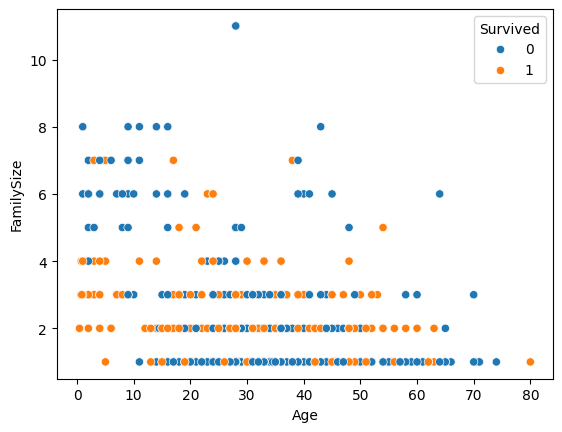

In [36]:
# Age + FamilySize → Survived
# 어린 승객 생존 높음
# 적당한 가족 규모가 유리
# 혼자 또는 너무 큰 가족은 생존률 감소

# 다변량 분석 최종 결론
# 성별 영향이 가장 큼
# 높은 객실 + 높은 운임 유리
# 나이 영향은 상대적으로 약해 보이나 나이 대별로는 생존률 차이가 남
# 가족규모는 적당할 때 생존증가

# 개인적 분석 희망
# 1. 캐빈 컬럼을 삭제 하지 않고, 결측치를 없음(0) 으로 채우고 분석
# 2. 가족규모는 적당할 때 생존률 증가 하였는데, 아이가 있는 가족을 우선 구조 되었을까 ? => 분석희망
# 3. Age 결측치 처리시, Pclass 등급별 평균 또는 중앙값으로 대체시 분석

result=(df_train.groupby(["FamilySize","Survived"])["Age"].mean())
print(result.round(1))


sns.scatterplot(x="Age",y="FamilySize",hue="Survived",data=df_train)

In [ ]:
# 통계적 가설검정

# EDA
# ↓
# 가설 설정
# ↓
# 통계 검정
# ↓
# p-value 해석
# ↓
# 결론


In [39]:
# 1. 객실 등급(Pclass)이 생존에 영향을 주는가?
# 객실 등급에 따라 생존률 차이가 정말 있는가?
# 아니면 우연인가?

# 귀무가설 : 객실 등급과 생존은 관계 없다.
# 대립가설 : 객실 등급과 생존은 관계 있다.

# 카이제곱 검정 (범주형 , 범주형)
# 사용 이유
# Pclass > 범주형
# Survived > 범주형

from scipy.stats import chi2_contingency

table = pd.crosstab(df_train["Pclass"],df_train["Survived"])
print(table)

st,pv,_,_ = chi2_contingency(table)

print("통계량 :",st)
print("p-value :",pv)

# 결론 
# p < 0.05보다 작음
# 대립가설 객실 등급과 생존은 통계적으로 유의미한 관계가 있다.


Survived    0    1
Pclass            
1          80  136
2          97   87
3         372  119
통계량 : 102.88898875696056
p-value : 4.549251711298793e-23


In [ ]:
# 생존자와 사망의 평균 운임(Fare)은 차이가 있는가?
# 생존자 운임이 높아 보이는데 진짜 차이가 있나

# 귀무가설 생존자와 사망자의 평균운임은 같다
# 대립가설 평균 운임이 다르다

# 두 집단이 다르므로 독립표본 t검정

from scipy.stats import ttest_ind

alive_fare = df_train[df_train["Survived"]== 1]["Fare"]
dead_fare = df_train[df_train["Survived"]== 0]["Fare"]

st, pv = ttest_ind(alive_fare,dead_fare)

print("t값 :",st)
print("p-value :",pv)

# p-value < 0.05
# 평균 차이가 존재
# 생존자는 사망자 보다 운임이 높다고 볼수 있다.

t값 : 7.939191660871055
p-value : 6.120189341924198e-15
